# Tip Amount Prediction using Random Forest

## Project Description
This project predicts the **tip amount** given by restaurant customers using bill amount, table size, day, time, gender, and smoking status. The goal is to understand which customer and transaction factors influence tipping behavior so that restaurant managers can improve service planning, staffing, and revenue estimation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 1. Load Dataset

In [2]:
file_path = 'tips.xlsx'
df = pd.read_excel(file_path, sheet_name='tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 2. Data Understanding
The target variable is `tip`, so this is a **regression problem**.

In [3]:
print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
df.describe()

Shape: (244, 7)

Data Types:
total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object

Missing Values:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## 3. Exploratory Data Analysis

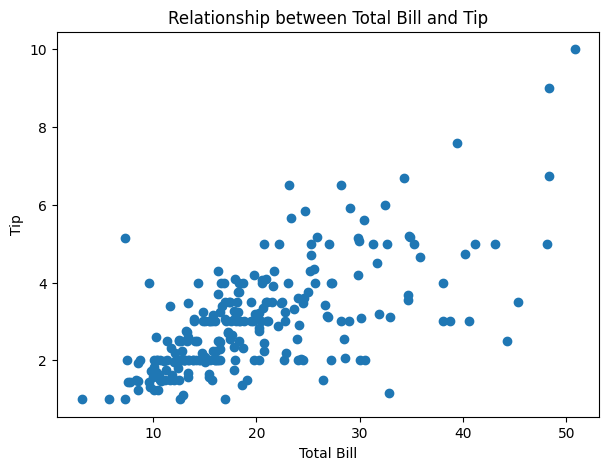

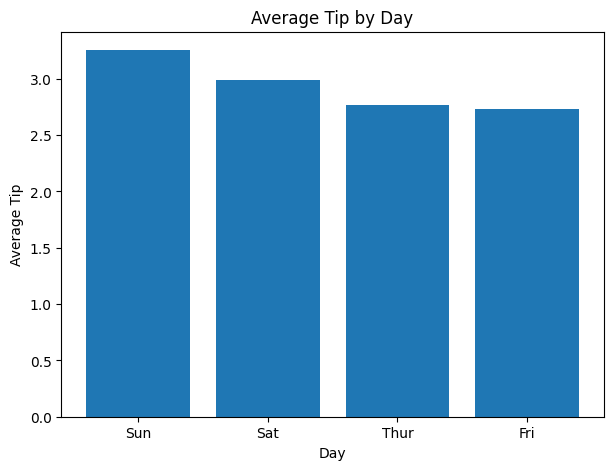

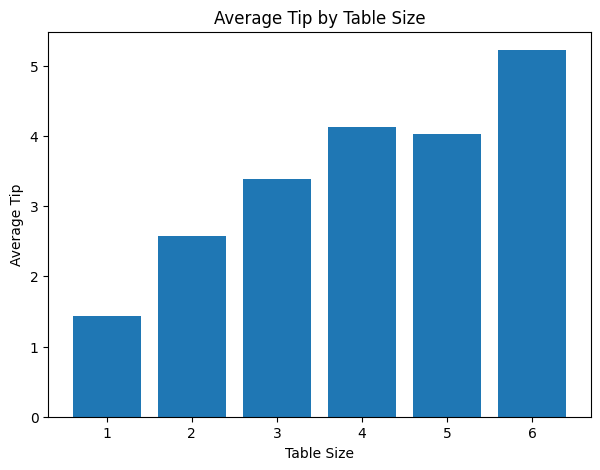

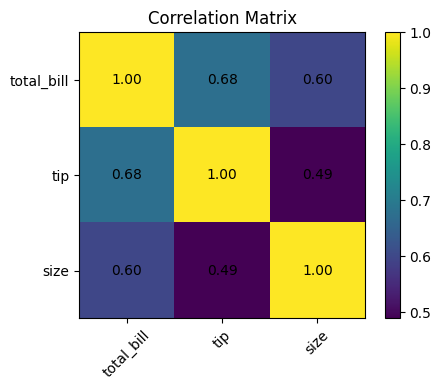

In [4]:
# Relationship between total bill and tip
plt.figure(figsize=(7, 5))
plt.scatter(df['total_bill'], df['tip'])
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Relationship between Total Bill and Tip')
plt.show()

# Average tip by day
avg_tip_day = df.groupby('day')['tip'].mean().sort_values(ascending=False)
plt.figure(figsize=(7, 5))
plt.bar(avg_tip_day.index, avg_tip_day.values)
plt.xlabel('Day')
plt.ylabel('Average Tip')
plt.title('Average Tip by Day')
plt.show()

# Average tip by table size
avg_tip_size = df.groupby('size')['tip'].mean()
plt.figure(figsize=(7, 5))
plt.bar(avg_tip_size.index.astype(str), avg_tip_size.values)
plt.xlabel('Table Size')
plt.ylabel('Average Tip')
plt.title('Average Tip by Table Size')
plt.show()

# Correlation matrix
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(5, 4))
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
plt.colorbar()
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
plt.tight_layout()
plt.show()

## 4. Business Observations from EDA
- Higher `total_bill` values generally lead to higher tip amounts.
- Larger table sizes usually generate higher tips because the bill amount is higher.
- Dinner orders have slightly higher average tips than lunch orders.
- Sunday has the highest average tip among the available days in this dataset.
- There are no missing values, so no major data cleaning issue is present.

In [5]:
eda_summary = pd.DataFrame({
    'Metric': ['Average Total Bill', 'Average Tip', 'Median Tip', 'Maximum Tip', 'Average Table Size'],
    'Value': [
        round(df['total_bill'].mean(), 2),
        round(df['tip'].mean(), 2),
        round(df['tip'].median(), 2),
        round(df['tip'].max(), 2),
        round(df['size'].mean(), 2)
    ]
})
eda_summary

,Metric,Value
0,Average Total Bill,19.79
1,Average Tip,3.00
2,Median Tip,2.90
3,Maximum Tip,10.00
4,Average Table Size,2.57


## 5. Model Building
The categorical columns are handled using `OneHotEncoder` inside a pipeline.

In [6]:
X = df.drop(columns=['tip'])
y = df['tip']

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=3,
        random_state=42
    ))
])

## 6. Model Evaluation

In [7]:
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2')
    return {
        'Model': name,
        'MAE': round(mae, 3),
        'RMSE': round(rmse, 3),
        'Test R2': round(r2, 3),
        'CV R2 Mean': round(cv_r2.mean(), 3)
    }

results = pd.DataFrame([
    evaluate_model('Linear Regression', linear_model),
    evaluate_model('Random Forest Regressor', rf_model)
])
results

,Model,MAE,RMSE,Test R2,CV R2 Mean
0,Linear Regression,0.667,0.839,0.437,0.421
1,Random Forest Regressor,0.717,0.904,0.347,0.399


## 7. Final Random Forest Prediction Check

In [8]:
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

prediction_sample = pd.DataFrame({
    'Actual Tip': y_test.values,
    'Predicted Tip': np.round(y_pred, 2),
    'Error': np.round(y_test.values - y_pred, 2)
})
prediction_sample.head(10)

,Actual Tip,Predicted Tip,Error
0,3.18,2.89,0.29
1,2.00,2.44,-0.44
2,2.00,4.10,-2.10
3,5.16,3.38,1.78
4,2.00,1.93,0.07
5,2.00,3.41,-1.41
6,2.56,3.78,-1.22
7,2.52,1.85,0.67
8,3.23,2.32,0.91
9,3.00,2.53,0.47


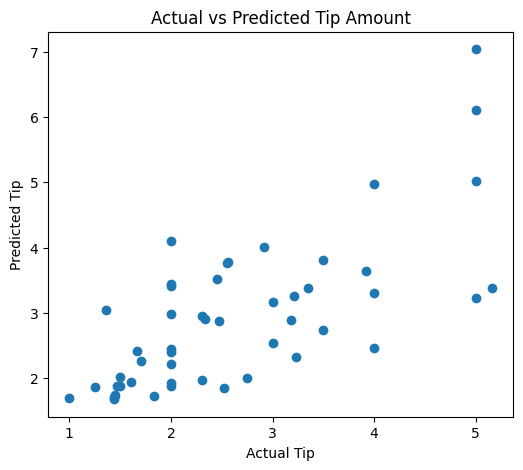

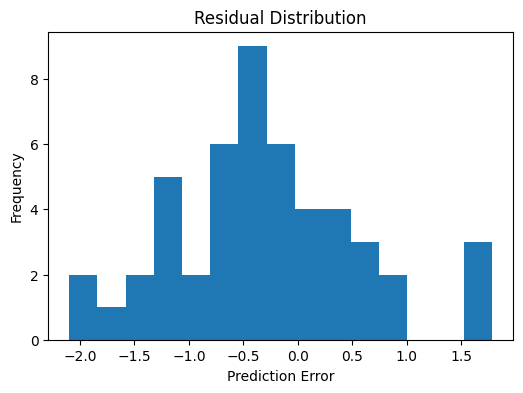

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Tip')
plt.ylabel('Predicted Tip')
plt.title('Actual vs Predicted Tip Amount')
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=15)
plt.title('Residual Distribution')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.show()

## 8. Feature Importance

In [10]:
feature_names = numeric_features.copy()
encoded_features = rf_model.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['onehot'] \
    .get_feature_names_out(categorical_features)

feature_names.extend(encoded_features)

importances = rf_model.named_steps['model'].feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
feature_importance_df.head(10)

,Feature,Importance
0,total_bill,0.801403
1,size,0.052121
4,smoker_No,0.036387
5,smoker_Yes,0.030226
7,day_Sat,0.027403
8,day_Sun,0.024726
3,sex_Male,0.007949
2,sex_Female,0.006551
9,day_Thur,0.005421
10,time_Dinner,0.003805


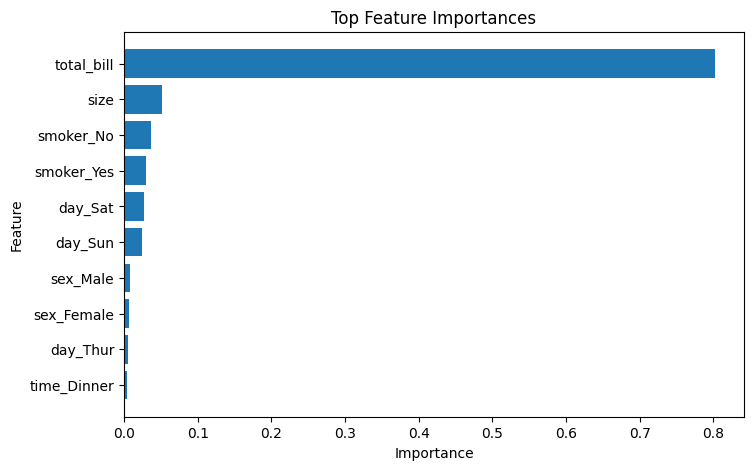

In [11]:
top_features = feature_importance_df.head(10)
plt.figure(figsize=(8, 5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top Feature Importances')
plt.gca().invert_yaxis()
plt.show()

## Observations

- `total_bill` is the strongest predictor of tip amount.
- Random Forest provides useful feature-importance insights, but Linear Regression performed slightly better on this small dataset.
- The model explains part of the variation in tips, but tipping behavior also depends on human and service-related factors not available in the dataset.

## Conclusion
The analysis shows that bill amount and table size are the most important drivers of tip amount. The notebook uses a proper preprocessing pipeline.

For business use, the model can help restaurants estimate expected tips, understand customer spending behavior, and support staffing or service planning.